In [16]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/valo.csv")

df.head(2)


,idx,match-datetime,patch,map,team1,team2,team1-score,team2-score,player-name,player-team,...,hs-ct,fk,fk-t,fk-ct,fd,fd-t,fd-ct,fkmd,fkmd-t,fkmd-ct
0,0,2023/4/16 10:00,6.06,Haven,Impulse GW,EGN Esports,13,6,HolyM0Ly,Impulse GW,...,0.26,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
1,1,2023/4/16 10:00,6.06,Haven,Impulse GW,EGN Esports,13,6,Dolfo,Impulse GW,...,0.38,0.0,0.0,0.0,1.0,1.0,0.0,-1.0,-1.0,0.0


In [17]:
drop_cols = [
    col for col in df.columns
    if any(x in col for x in ['-t', '-ct', 'idx']) and col not in ['player-team']
]
df = df.drop(columns=drop_cols)


In [18]:
df.head(2)

,match-datetime,patch,map,team1,team2,team1-score,team2-score,player-name,player-team,agent,...,k,d,a,tkmd,kast,adr,hs,fk,fd,fkmd
0,2023/4/16 10:00,6.06,Haven,Impulse GW,EGN Esports,13,6,HolyM0Ly,Impulse GW,Killjoy,...,20.0,11.0,1.0,9.0,0.68,160.0,0.31,1.0,1.0,0.0
1,2023/4/16 10:00,6.06,Haven,Impulse GW,EGN Esports,13,6,Dolfo,Impulse GW,Breach,...,16.0,13.0,14.0,3.0,0.84,158.0,0.41,0.0,1.0,-1.0


In [19]:
team_stats = df.groupby(['match-datetime', 'map', 'player-team']).agg({
    'rating': 'mean',
    'acs': 'mean',
    'k': 'sum',
    'd': 'sum',
    'a': 'sum',
    'tkmd': 'sum',
    'kast': 'mean',
    'adr': 'mean',
    'hs': 'mean',
    'fk': 'sum',
    'fd': 'sum',
    'fkmd': 'sum'
}).reset_index()


In [21]:
# Convert score columns to numeric
team_stats['team1-score'] = pd.to_numeric(team_stats['team1-score'], errors='coerce')
team_stats['team2-score'] = pd.to_numeric(team_stats['team2-score'], errors='coerce')


In [22]:
# Merge scores from original dataframe
scores = df[['match-datetime', 'team1', 'team2', 'team1-score', 'team2-score']].drop_duplicates()
team_stats = team_stats.merge(scores, on='match-datetime', how='left')

# Assign win = 1 if the team won, else 0
team_stats['win'] = team_stats.apply(
    lambda x: 1 if (
        (x['player-team'] == x['team1'] and x['team1-score'] > x['team2-score']) or
        (x['player-team'] == x['team2'] and x['team2-score'] > x['team1-score'])
    ) else 0,
    axis=1
)



KeyError: 'team1'

In [23]:
scores = df[['match-datetime', 'team1', 'team2', 'team1-score', 'team2-score']].drop_duplicates(subset=['match-datetime'])
team_stats = team_stats.merge(scores, on='match-datetime', how='left', validate='many_to_one')


In [24]:
team_stats.columns


Index(['match-datetime', 'map', 'player-team', 'rating', 'acs', 'k', 'd', 'a',
       'tkmd', 'kast', 'adr', 'hs', 'fk', 'fd', 'fkmd', 'team1_x', 'team2_x',
       'team1-score_x', 'team2-score_x', 'team1_y', 'team2_y', 'team1-score_y',
       'team2-score_y', 'team1', 'team2', 'team1-score', 'team2-score'],
      dtype='object')

In [25]:
team_stats['team1-score'] = pd.to_numeric(team_stats['team1-score'], errors='coerce')
team_stats['team2-score'] = pd.to_numeric(team_stats['team2-score'], errors='coerce')


In [27]:
# Ensure scores are numeric
team_stats['team1-score'] = pd.to_numeric(team_stats['team1-score'], errors='coerce')
team_stats['team2-score'] = pd.to_numeric(team_stats['team2-score'], errors='coerce')

# Initialize win column to 0
team_stats['win'] = 0

# Winning condition for team1
mask_team1 = (team_stats['player-team'] == team_stats['team1']) & (team_stats['team1-score'] > team_stats['team2-score'])

# Winning condition for team2
mask_team2 = (team_stats['player-team'] == team_stats['team2']) & (team_stats['team2-score'] > team_stats['team1-score'])

# Apply both masks efficiently
team_stats.loc[mask_team1 | mask_team2, 'win'] = 1


In [28]:
import pandas as pd
import numpy as np

def preprocess_valorant_data(filepath: str):
    """
    Load and preprocess Valorant match data for team-level win prediction.
    Handles large datasets efficiently and prepares features for ML models.
    """

    # 1️⃣ Load CSV
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()  # clean any stray spaces

    # 2️⃣ Drop unneeded per-side stats and index column — keep player-team safe
    drop_cols = [
        col for col in df.columns
        if any(x in col for x in ['-t', '-ct', 'idx']) and col not in ['player-team']
    ]
    df = df.drop(columns=drop_cols, errors='ignore')

    # 3️⃣ Convert numeric columns properly
    numeric_cols = ['team1-score', 'team2-score', 'rating', 'acs', 'k', 'd', 'a', 'tkmd',
                    'kast', 'adr', 'hs', 'fk', 'fd', 'fkmd']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 4️⃣ Aggregate to team level (average / sum stats per match)
    team_stats = df.groupby(['match-datetime', 'map', 'player-team'], as_index=False).agg({
        'rating': 'mean',
        'acs': 'mean',
        'k': 'sum',
        'd': 'sum',
        'a': 'sum',
        'tkmd': 'sum',
        'kast': 'mean',
        'adr': 'mean',
        'hs': 'mean',
        'fk': 'sum',
        'fd': 'sum',
        'fkmd': 'sum'
    })

    # 5️⃣ Get scores per match
    scores = df[['match-datetime', 'team1', 'team2', 'team1-score', 'team2-score']].drop_duplicates(subset=['match-datetime'])
    team_stats = team_stats.merge(scores, on='match-datetime', how='left', validate='many_to_one')

    # 6️⃣ Create win label (vectorized, efficient)
    team_stats['win'] = 0
    mask_team1 = (team_stats['player-team'] == team_stats['team1']) & (team_stats['team1-score'] > team_stats['team2-score'])
    mask_team2 = (team_stats['player-team'] == team_stats['team2']) & (team_stats['team2-score'] > team_stats['team1-score'])
    team_stats.loc[mask_team1 | mask_team2, 'win'] = 1

    # 7️⃣ Final feature set
    features = ['rating', 'acs', 'k', 'd', 'a', 'tkmd', 'kast', 'adr', 'hs', 'fk', 'fd', 'fkmd']
    team_stats = team_stats.dropna(subset=features + ['win'])

    print(f"✅ Preprocessing complete: {len(team_stats)} team-level samples ready.")
    return team_stats, features


In [30]:
team_stats, features = preprocess_valorant_data("data/valo.csv")

X = team_stats[features]
y = team_stats['win']


✅ Preprocessing complete: 49991 team-level samples ready.


In [31]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6925692569256926
              precision    recall  f1-score   support

           0       0.75      0.83      0.79      6907
           1       0.50      0.39      0.44      3092

    accuracy                           0.69      9999
   macro avg       0.63      0.61      0.61      9999
weighted avg       0.67      0.69      0.68      9999



In [32]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import joblib
import numpy as np

def train_and_compare_models(X, y):
    """
    Train multiple ML models on Valorant team stats and compare their accuracies.
    Automatically saves the best model to disk.
    """

    # 1️⃣ Define candidate models
    models = {
        "Logistic Regression": LogisticRegression(max_iter=500),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
    }

    # 2️⃣ Prepare K-Fold Cross-Validation
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    results = {}

    print("🔍 Evaluating models using 5-Fold Cross Validation...\n")
    for name, model in models.items():
        cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy', n_jobs=-1)
        results[name] = np.mean(cv_scores)
        print(f"{name:20s} | Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # 3️⃣ Find the best model
    best_model_name = max(results, key=results.get)
    print(f"\n🏆 Best Model: {best_model_name} with Mean Accuracy = {results[best_model_name]:.4f}")

    # 4️⃣ Train best model on full dataset
    best_model = models[best_model_name]
    best_model.fit(X, y)

    # 5️⃣ Save model
    model_path = f"models/valorant_best_{best_model_name.replace(' ', '_')}.pkl"
    joblib.dump(best_model, model_path)
    print(f"✅ Saved best model to {model_path}")

    # 6️⃣ Visualize leaderboard
    plt.figure(figsize=(10, 5))
    plt.barh(list(results.keys()), list(results.values()), color='skyblue')
    plt.xlabel('Mean Accuracy (5-Fold CV)')
    plt.ylabel('Model')
    plt.title('Valorant Win Prediction Model Comparison')
    plt.gca().invert_yaxis()
    plt.show()

    return best_model_name, results


✅ Preprocessing complete: 49991 team-level samples ready.
🔍 Evaluating models using 5-Fold Cross Validation...

Logistic Regression  | Mean Accuracy: 0.6818 ± 0.0035
Decision Tree        | Mean Accuracy: 0.6212 ± 0.0043
Random Forest        | Mean Accuracy: 0.6864 ± 0.0024
Gradient Boosting    | Mean Accuracy: 0.6931 ± 0.0016
AdaBoost             | Mean Accuracy: 0.6834 ± 0.0048
XGBoost              | Mean Accuracy: 0.6877 ± 0.0034

🏆 Best Model: Gradient Boosting with Mean Accuracy = 0.6931
✅ Saved best model to models/valorant_best_Gradient_Boosting.pkl


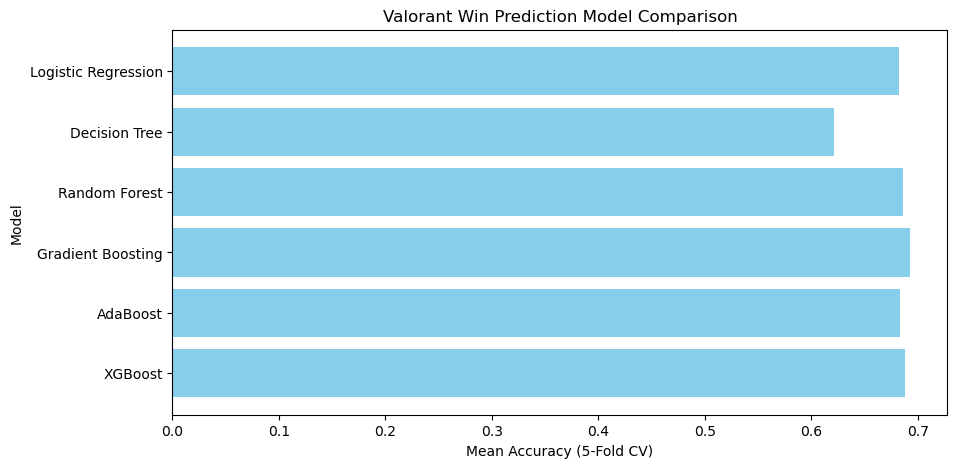

In [33]:
# Preprocess dataset
team_stats, features = preprocess_valorant_data("data/valo.csv")

X = team_stats[features]
y = team_stats['win']

# Train and compare models
best_model_name, results = train_and_compare_models(X, y)
